# PMF Projekt — Datenanalyse & Systemvergleich
**TU Berlin · Fachgebiet Handhabungs- und Montagetechnik**

Dieses Notebook enthält alle Analysen und Visualisierungen des Projekts:
1. Setup & Arbeitsverzeichnis
2. Hilfsfunktionen & Daten laden
3. Zenerdiode Benchmarking — OHNE vs. MIT 1N5333B (3,3 V)
4. Pi-System Messungen — Messung 1 (statisch) & Messung 2 (Zellenradschleuse)
5. Systemvergleich — Pi-System vs. Referenzsystem (Beckhoff EL3174)
6. Statistische Zusammenfassung

**Benötigte CSV-Dateien** (müssen im selben Ordner wie dieses Notebook liegen):
- `zener_ohne_distance.csv`, `zener_ohne_pressure.csv`
- `zener_mit_distance.csv`, `zener_mit_pressure.csv`
- `pi_messung1_distance.csv`, `pi_messung1_pressure.csv`
- `pi_messung2_distance.csv`, `pi_messung2_pressure.csv`
- `messung_1-2.csv`, `Messung_2-2.csv`


## 1. Setup & Arbeitsverzeichnis

In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Arbeitsverzeichnis automatisch auf Notebook-Ordner setzen ─────────────────
# Dadurch können CSV-Dateien mit einfachem Dateinamen (ohne Pfad) geöffnet werden,
# egal von wo aus Jupyter gestartet wurde.
try:
    # Funktioniert in JupyterLab und klassischem Notebook
    notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    try:
        # Fallback für ältere Jupyter-Versionen
        from IPython import get_ipython
        notebook_dir = os.path.dirname(
            get_ipython().run_line_magic('config', 'Application.name')
        )
    except:
        # Letzter Fallback: aktuelles Verzeichnis beibehalten
        notebook_dir = os.getcwd()

os.chdir(notebook_dir)
print(f"Arbeitsverzeichnis gesetzt: {os.getcwd()}")

# Prüfen ob alle CSV-Dateien vorhanden sind
required_files = [
    'zener_ohne_distance.csv', 'zener_ohne_pressure.csv',
    'zener_mit_distance.csv',  'zener_mit_pressure.csv',
    'pi_messung1_distance.csv','pi_messung1_pressure.csv',
    'pi_messung2_distance.csv','pi_messung2_pressure.csv',
    'messung_1-2.csv',         'Messung_2-2.csv',
]
found    = [f for f in required_files if os.path.exists(f)]
missing  = [f for f in required_files if not os.path.exists(f)]
print(f"\nGefunden ({len(found)}/{len(required_files)}):")
for f in found:   print(f"  OK  {f}")
for f in missing: print(f"  FEHLT  {f}")


Arbeitsverzeichnis gesetzt: /Users/umutdurak/Documents/PMF/embedded/pi-industrial-monitor/data

Gefunden (10/10):
  OK  zener_ohne_distance.csv
  OK  zener_ohne_pressure.csv
  OK  zener_mit_distance.csv
  OK  zener_mit_pressure.csv
  OK  pi_messung1_distance.csv
  OK  pi_messung1_pressure.csv
  OK  pi_messung2_distance.csv
  OK  pi_messung2_pressure.csv
  OK  messung_1-2.csv
  OK  Messung_2-2.csv


In [2]:
# ── Bibliotheken konfigurieren ────────────────────────────────────────────────

# TU Berlin Farben (aus dem offiziellen Corporate Design)
C_RED  = '#C30D1E'   # TU Rot  — Pi-System / OHNE Zener
C_BLUE = '#185FA5'   # Blau    — Referenzsystem / MIT Zener
C_GRAY = '#434343'   # Anthrazit für Achsen und Linien
C_MUTED = '#94a3b8'  # Helles Grau für Achsenbeschriftungen

# Matplotlib Grundeinstellungen
plt.rcParams['figure.facecolor'] = 'white'   # weißer Hintergrund
plt.rcParams['axes.facecolor']   = 'white'   # weißer Plot-Hintergrund
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['axes.grid']        = True      # Gitter standardmäßig an
plt.rcParams['grid.alpha']       = 0.25      # Gitter halbtransparent
plt.rcParams['grid.linewidth']   = 0.5       # dünne Gitterlinien

print("Bibliotheken konfiguriert.")
print(f"  TU Rot:  {C_RED}")
print(f"  Blau:    {C_BLUE}")


Bibliotheken konfiguriert.
  TU Rot:  #C30D1E
  Blau:    #185FA5


## 2. Hilfsfunktionen & Daten laden

### 2.1 Hilfsfunktionen

In [3]:
def load_pi_csv(path):
    """
    Laedt Pi-Messdaten aus einer CSV-Datei.
    
    Erwartet zwei Spalten: 'time_s' (Zeit in Sekunden seit Messbeginn)
    und 'value' (Messwert in physikalischer Einheit: mm oder bar).
    
    Die Zeitnormalisierung erfolgt bereits beim Export aus InfluxDB:
    t=0 entspricht dem ersten Messpunkt der jeweiligen Zeitreihe.
    
    Parameter:
        path (str): Pfad zur CSV-Datei
    
    Rueckgabe:
        times  (np.array): Zeit in Sekunden
        values (np.array): Messwerte in der jeweiligen Einheit
    """
    times, values = [], []
    with open(path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            times.append(float(row['time_s']))
            values.append(float(row['value']))
    return np.array(times), np.array(values)


def load_ref_csv(path):
    """
    Laedt Rohdaten des Beckhoff Referenzsystems und konvertiert sie in physikalische Einheiten.
    
    Das Beckhoff-System speichert Messwerte als INT16-Rohwerte (0-32767).
    Die Konvertierung erfolgt mit dem Beckhoff EL3174 Extended Range Scaler:
    
        100% des Messbereichs = 30518 counts  (nicht 32767!)
        107% des Messbereichs = 32767 counts  (maximaler INT16-Wert)
    
    Grund fuer den Extended Range: Die EL3174-Klemme erlaubt 107% Ueberbereich,
    damit Signale leicht ausserhalb des Nennbereichs nicht geclipt werden.
    Dies ist im Beckhoff-Datenblatt unter 'Technical Measuring Range' dokumentiert.
    
    Distanzsensor (Baumer UB200, 0-10V Ausgang, Normalmodus: 0V=15mm, 10V=500mm):
        Spannungsteiler-Umkehrung:  voltage  = raw / 30518 x 10     [V]
        Distanzumrechnung:          distance = (voltage/10) x 485 + 15  [mm]
        Sensorbereich: 15-500mm, Spanne = 485mm
    
    Drucksensor (Baumer PP20H, 4-20mA Ausgang, 0-1 bar):
        Strom-Umrechnung:  current  = 4 + (raw / 30518) x 16    [mA]
        Druckumrechnung:   pressure = (current - 4) / 16 x 1.0  [bar]
        Nullpunkt bei 4mA (0 bar), Vollausschlag bei 20mA (1 bar)
    
    Parameter:
        path (str): Pfad zur CSV-Datei des Beckhoff-Systems
    
    Rueckgabe:
        t        (np.array): Zeit in Sekunden (1ms Schritte, 1kHz Abtastrate)
        dist_mm  (np.array): Distanz in mm
        pres_bar (np.array): Druck in bar
    """
    dist_raw, pres_raw = [], []

    # CSV einlesen — Beckhoff-Dateien haben einen mehrzeiligen Header
    # Datenzeilen beginnen mit einer Zahl (Zeitstempel)
    with open(path, newline='', encoding='utf-8-sig') as f:
        content = f.read()
    lines = content.replace('\r\n', '\n').split('\n')

    # Erste Datenzeile finden (erste Zeile, die mit einer Ziffer beginnt)
    data_start = 0
    for i, line in enumerate(lines):
        if line.strip() and line.strip()[0].isdigit():
            data_start = i
            break

    # Daten zeilenweise einlesen
    # Format: Zeit_ms, nS9 (Distanz-Rohwert), Zeit_ms, nS12 (Druck-Rohwert)
    for line in lines[data_start:]:
        parts = line.strip().split(',')
        if len(parts) >= 4 and parts[0].strip().isdigit():
            try:
                dist_raw.append(int(parts[1]))   # nS9: Distanzsensor INT16
                pres_raw.append(int(parts[3]))   # nS12: Drucksensor INT16
            except:
                pass  # fehlerhafte Zeilen ueberspringen

    d = np.array(dist_raw)
    p = np.array(pres_raw)

    # Beckhoff EL3174 Extended Range Scaler: 100% = 30518 counts
    FS = 30518

    # Distanz konvertieren: INT16 -> Spannung -> Distanz in mm
    voltage  = d / FS * 10               # Spannung am Sensor [V]
    dist_mm  = (voltage / 10) * 485 + 15 # Distanz [mm], normal mode

    # Druck konvertieren: INT16 -> Strom -> Druck in bar
    current_ma = 4 + (p / FS) * 16       # Strom [mA], 4mA=0bar, 20mA=1bar
    pres_bar   = np.maximum(0.0, (current_ma - 4) / 16)  # Druck [bar], >= 0

    # Zeitachse erzeugen: 1ms Schritte (Abtastrate 1kHz)
    t = np.arange(len(dist_mm)) * 0.001

    return t, dist_mm, pres_bar


def stats(v):
    """
    Berechnet grundlegende Statistiken fuer ein Messwert-Array.
    
    Parameter:
        v (np.array): Messwerte
    
    Rueckgabe:
        mean (float): Arithmetischer Mittelwert
        std  (float): Standardabweichung (empirisch)
        min  (float): Minimaler Messwert
        max  (float): Maximaler Messwert
    """
    return np.mean(v), np.std(v), np.min(v), np.max(v)


print("Hilfsfunktionen definiert.")
print("  load_pi_csv()   -> laedt Pi-Messdaten (time_s, value)")
print("  load_ref_csv()  -> laedt Beckhoff INT16-Daten und konvertiert")
print("  stats()         -> MW, Std, Min, Max")


Hilfsfunktionen definiert.
  load_pi_csv()   -> laedt Pi-Messdaten (time_s, value)
  load_ref_csv()  -> laedt Beckhoff INT16-Daten und konvertiert
  stats()         -> MW, Std, Min, Max


### 2.2 Zenerdiode Benchmarking Daten laden

In [4]:
# ── Zenerdiode Benchmarking (17.07.2026) ────────────────────────────────────
#
# Versuchsaufbau:
#   - Distanzsensor bei festem Objekt (~110mm), keine Bewegung
#   - Drucksensor misst Atmosphaerendruck (kein externer Druck)
#   - Beide Messungen unter identischen Bedingungen durchgefuehrt
#
# Zeitfenster (UTC, Pi-System):
#   OHNE Zener: 11:39:41 - 11:42:15  (ca. 2.5 Minuten)
#   MIT  Zener: 11:33:04 - 11:36:32  (ca. 3.5 Minuten)
#
# Diode: 1N5333B (Zener, Durchbruchspannung 3.3V)
#         parallel zum ADC-Eingang geschaltet
#         Max. ADC-Eingangsspannung: 2.41V (nach Spannungsteiler 33k/10.5k)

t_ohne_d, v_ohne_d = load_pi_csv('zener_ohne_distance.csv')  # Distanz OHNE Zener [mm]
t_ohne_p, v_ohne_p = load_pi_csv('zener_ohne_pressure.csv')  # Druck   OHNE Zener [bar]
t_mit_d,  v_mit_d  = load_pi_csv('zener_mit_distance.csv')   # Distanz MIT  Zener [mm]
t_mit_p,  v_mit_p  = load_pi_csv('zener_mit_pressure.csv')   # Druck   MIT  Zener [bar]

print("Zenerdiode-Daten geladen:")
print(f"  OHNE Zener: {len(v_ohne_d)} Distanz-Messungen, {len(v_ohne_p)} Druck-Messungen")
print(f"  MIT  Zener: {len(v_mit_d)} Distanz-Messungen, {len(v_mit_p)} Druck-Messungen")


Zenerdiode-Daten geladen:
  OHNE Zener: 147 Distanz-Messungen, 147 Druck-Messungen
  MIT  Zener: 208 Distanz-Messungen, 208 Druck-Messungen


### 2.3 Pi-System Messungen laden

In [5]:
# ── Pi-System Systemvergleich-Messungen (22.07.2026) ─────────────────────────
#
# Messung 1 (stationaer):
#   - Distanzsensor (Baumer UB200): festes Objekt bei ~110mm
#   - Drucksensor (Baumer PP20H): Atmosphaerendruck Berlin (~1026 hPa)
#   - Zeitfenster UTC: 08:42:47 - 08:47:51 (5 Minuten)
#
# Messung 2 (Zellenradschleuse):
#   - Distanzsensor: misst rotierendes Zellenrad (5 rpm)
#   - Drucksensor: misst Ueberdruck durch aktives Geblaese
#   - Zeitfenster UTC: 08:57:30 - 09:02:30 (5 Minuten)
#
# Hinweis: Beide Messungen wurden rueckwirkend aus InfluxDB exportiert.
#          Die Zeitnormalisierung (t=0 = erster Messpunkt) erfolgte beim Export.

t_pi1_d, v_pi1_d = load_pi_csv('pi_messung1_distance.csv')  # M1 Distanz [mm]
t_pi1_p, v_pi1_p = load_pi_csv('pi_messung1_pressure.csv')  # M1 Druck   [bar]
t_pi2_d, v_pi2_d = load_pi_csv('pi_messung2_distance.csv')  # M2 Distanz [mm]
t_pi2_p, v_pi2_p = load_pi_csv('pi_messung2_pressure.csv')  # M2 Druck   [bar]

print("Pi-System-Daten geladen:")
print(f"  Messung 1: {len(v_pi1_d)} Distanz-Messungen, {len(v_pi1_p)} Druck-Messungen")
print(f"  Messung 2: {len(v_pi2_d)} Distanz-Messungen, {len(v_pi2_p)} Druck-Messungen")


Pi-System-Daten geladen:
  Messung 1: 296 Distanz-Messungen, 296 Druck-Messungen
  Messung 2: 291 Distanz-Messungen, 291 Druck-Messungen


### 2.4 Referenzsystem Daten laden (Beckhoff EL3174)

In [6]:
# ── Beckhoff Referenzsystem (22.07.2026) ────────────────────────────────────
#
# System: Beckhoff TwinCAT mit EL3174 Analogeingangsklemme
# Abtastrate: 1 kHz (1ms Intervall) — 100x hoeher als Pi-System (1 Hz)
# Datenformat: INT16 Rohwerte, zwei Kanaele pro Datei
#   - nS9:  Distanzsensor (Baumer UB200, 0-10V)
#   - nS12: Drucksensor (Baumer PP20H, 4-20mA)
#
# Konvertierung: Beckhoff EL3174 Extended Range Scaler
#   100% Messbereich = 30518 counts (nicht 32767!)
#   Grund: EL3174 unterstuetzt 107% Ueberbereich (32767/30518 = 1.073 = 107.3%)
#
# Fuer den visuellen Vergleich mit dem Pi-System (1Hz) werden die Referenzdaten
# auf 1Hz downgesampelt (jeder 1000. Messpunkt), d.h. 1 von 1000 Werten.
# Fuer statistische Auswertungen wird das vollstaendige 1kHz-Signal verwendet.

t_ref1, ref1_d, ref1_p = load_ref_csv('messung_1-2.csv')   # M1: stationaer
t_ref2, ref2_d, ref2_p = load_ref_csv('Messung_2-2.csv')   # M2: Zellenradschleuse

# Auf 1Hz downsampeln fuer Zeitverlauf-Plots (visueller Vergleich mit Pi)
# Statistiken werden weiterhin auf dem vollen 1kHz-Datensatz berechnet
ref1_d_ds = ref1_d[::1000]   # Distanz M1 downgesampelt
ref1_p_ds = ref1_p[::1000]   # Druck   M1 downgesampelt
ref2_d_ds = ref2_d[::1000]   # Distanz M2 downgesampelt
ref2_p_ds = ref2_p[::1000]   # Druck   M2 downgesampelt
t_ref1_ds = np.arange(len(ref1_d_ds))  # Zeitachse nach Downsampling [s]
t_ref2_ds = np.arange(len(ref2_d_ds))

print("Referenzsystem-Daten geladen und konvertiert:")
print(f"  Messung 1: {len(ref1_d):,} Punkte @ 1kHz -> downgesampelt auf {len(ref1_d_ds)} Punkte @ 1Hz")
print(f"  Messung 2: {len(ref2_d):,} Punkte @ 1kHz -> downgesampelt auf {len(ref2_d_ds)} Punkte @ 1Hz")
print(f"\nBeispielwerte Messung 1 (erste 3 Punkte):")
print(f"  Distanz: {ref1_d[:3]} mm")
print(f"  Druck:   {ref1_p[:3]} bar")


Referenzsystem-Daten geladen und konvertiert:
  Messung 1: 319,200 Punkte @ 1kHz -> downgesampelt auf 320 Punkte @ 1Hz
  Messung 2: 332,743 Punkte @ 1kHz -> downgesampelt auf 333 Punkte @ 1Hz

Beispielwerte Messung 1 (erste 3 Punkte):
  Distanz: [112.06992595 112.06992595 111.9268956 ] mm
  Druck:   [1.01323809 1.01317255 1.01281211] bar


## 3. Zenerdiode Benchmarking

**Diode:** 1N5333B (Zener, Durchbruchspannung 3,3 V)  
**Schaltung:** Parallel zum ADC-Eingang des MCP3208 (zwischen Signalleitung und GND)  
**Hypothese:** Die Diode soll durch ihre Sperrschichtkapazitaet als Tiefpassfilter wirken und Hochfrequenzrauschen daempfen.  
**Erwarteter Effekt:** Geringere Standardabweichung der Messwerte.

**Ergebnis:** Da die maximale ADC-Eingangsspannung (2,41 V nach dem Spannungsteiler 33 kΩ / 10,5 kΩ) 
deutlich unterhalb der Durchbruchspannung liegt (3,3 V), findet keine aktive Klemmwirkung statt. 
Der Kapazitaetseffekt ist zu gering um messbar zu sein.


In [7]:
# ── Statistische Auswertung Zenerdiode ───────────────────────────────────────
print("=" * 60)
print("BENCHMARKING - Zenerdiode 1N5333B (3.3V)")
print("=" * 60)

for name, unit, v_ohne, v_mit in [
    ("Distanzsensor", "mm",  v_ohne_d, v_mit_d),
    ("Drucksensor",   "bar", v_ohne_p, v_mit_p),
]:
    # Statistiken fuer beide Phasen berechnen
    m_o, s_o, mn_o, mx_o = stats(v_ohne)   # OHNE Zener
    m_m, s_m, mn_m, mx_m = stats(v_mit)    # MIT Zener

    # Prozentuale Aenderung der Standardabweichung berechnen
    # positiv = Rauschen reduziert, negativ = Rauschen erhoeht
    diff_pct = (s_o - s_m) / s_o * 100

    print(f"\n{name}:")
    print(f"  {'Metrik':<16} {'OHNE Zener':>14} {'MIT Zener':>14}")
    print(f"  {'':-<44}")
    print(f"  {'Mittelwert':<16} {m_o:>13.3f} {m_m:>13.3f}  {unit}")
    print(f"  {'Standardabw.':<16} {s_o:>13.4f} {s_m:>13.4f}  {unit}")
    print(f"  {'Min':<16} {mn_o:>13.3f} {mn_m:>13.3f}  {unit}")
    print(f"  {'Max':<16} {mx_o:>13.3f} {mx_m:>13.3f}  {unit}")
    print(f"  {'Messungen':<16} {len(v_ohne):>13} {len(v_mit):>13}")
    if diff_pct > 0:
        print(f"  -> Rauschen reduziert um {diff_pct:.1f}%")
    else:
        print(f"  -> Rauschen erhoet um {abs(diff_pct):.1f}% (kein Zener-Effekt)")


BENCHMARKING - Zenerdiode 1N5333B (3.3V)

Distanzsensor:
  Metrik               OHNE Zener      MIT Zener
  --------------------------------------------
  Mittelwert             109.963       108.920  mm
  Standardabw.            1.1326        1.2755  mm
  Min                    107.600       106.300  mm
  Max                    113.100       112.000  mm
  Messungen                  147           208
  -> Rauschen erhoet um 12.6% (kein Zener-Effekt)

Drucksensor:
  Metrik               OHNE Zener      MIT Zener
  --------------------------------------------
  Mittelwert               1.063         1.065  bar
  Standardabw.            0.0134        0.0135  bar
  Min                      1.023         1.023  bar
  Max                      1.105         1.098  bar
  Messungen                  147           208
  -> Rauschen erhoet um 0.2% (kein Zener-Effekt)


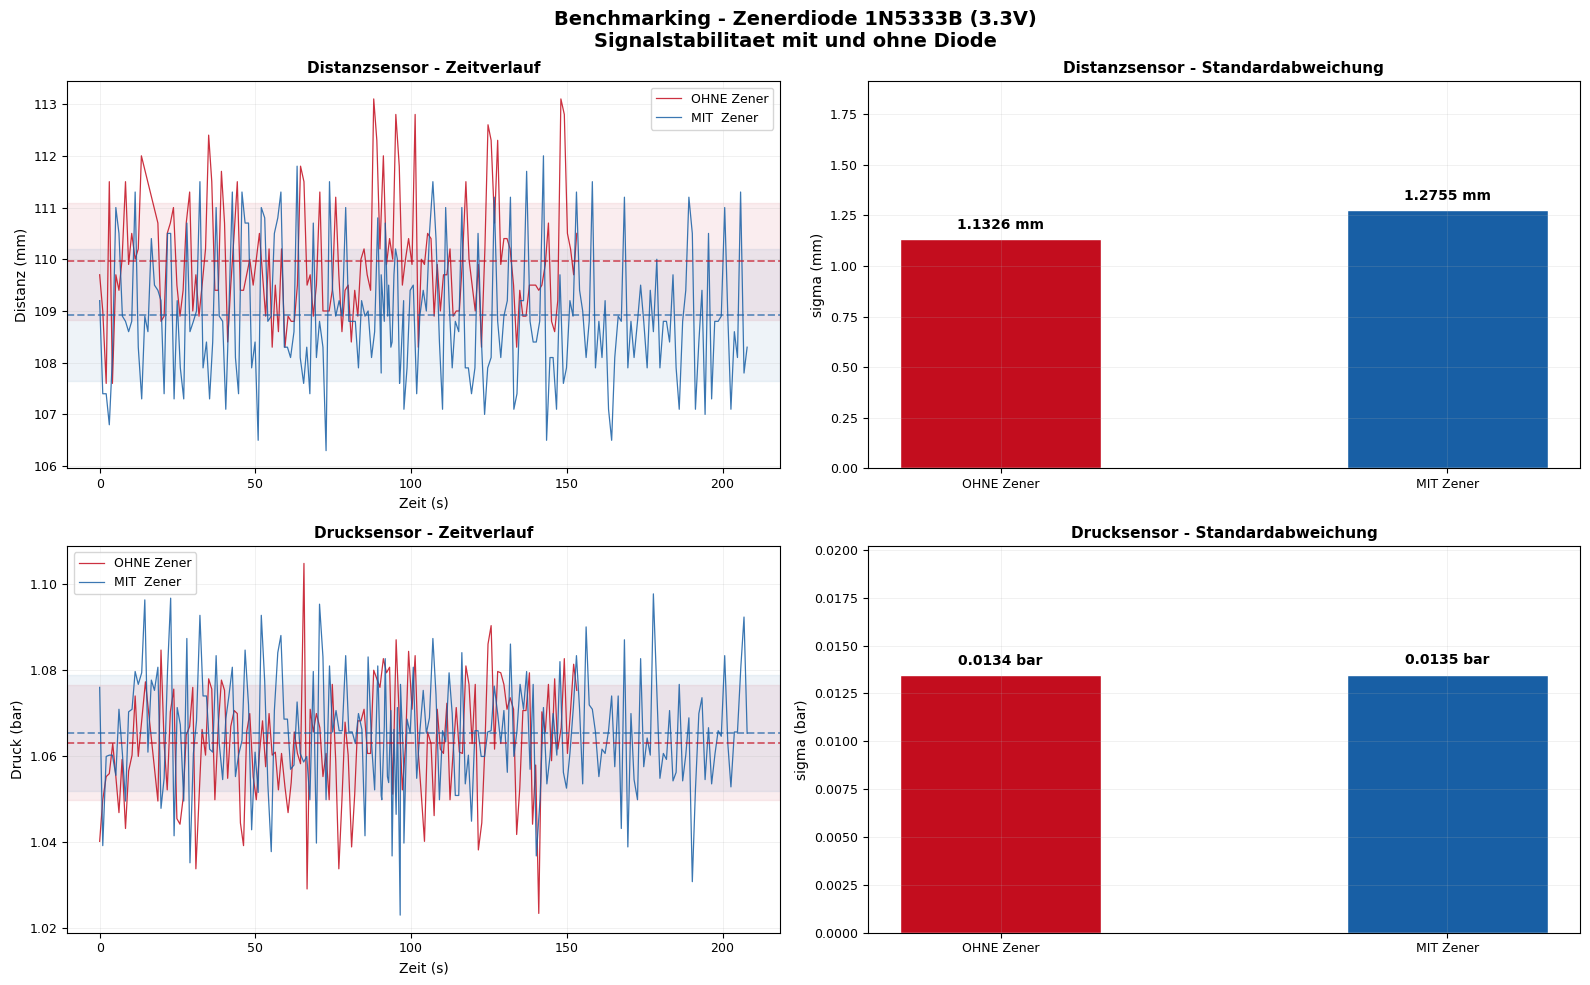

Plot gespeichert: zener_benchmarking.pdf


In [8]:
# ── Zenerdiode Visualisierung ─────────────────────────────────────────────────
# 2x2 Subplot-Layout:
#   Links:  Zeitverlauf beider Phasen ueberlagert (mit Mittelwertlinie + 1-sigma-Band)
#   Rechts: Standardabweichung als Balkendiagramm (direkter Vergleich)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Benchmarking - Zenerdiode 1N5333B (3.3V)\n'
             'Signalstabilitaet mit und ohne Diode',
             fontsize=14, fontweight='bold')

# Datensaetze fuer beide Sensoren
datasets = [
    (axes[0, 0], axes[0, 1],
     t_ohne_d, v_ohne_d, t_mit_d, v_mit_d,
     'Distanzsensor - Zeitverlauf', 'Distanz (mm)', 'mm'),
    (axes[1, 0], axes[1, 1],
     t_ohne_p, v_ohne_p, t_mit_p, v_mit_p,
     'Drucksensor - Zeitverlauf', 'Druck (bar)', 'bar'),
]

for ax_line, ax_bar, t_o, v_o, t_m, v_m, title, ylabel, unit in datasets:

    # ── Zeitverlauf-Plot ──────────────────────────────────────────────────────
    ax_line.plot(t_o, v_o, color=C_RED,  lw=0.9, alpha=0.85, label='OHNE Zener')
    ax_line.plot(t_m, v_m, color=C_BLUE, lw=0.9, alpha=0.85, label='MIT  Zener')

    # Mittelwertlinie und +/-1-sigma-Band fuer beide Phasen
    for v, c in [(v_o, C_RED), (v_m, C_BLUE)]:
        m, s = np.mean(v), np.std(v)
        ax_line.axhline(m, color=c, lw=1.4, ls='--', alpha=0.6)        # Mittelwert
        ax_line.axhspan(m - s, m + s, color=c, alpha=0.07)             # 1-sigma-Band

    ax_line.set_title(title, fontsize=11, fontweight='bold')
    ax_line.set_xlabel('Zeit (s)', fontsize=10)
    ax_line.set_ylabel(ylabel, fontsize=10)
    ax_line.legend(fontsize=9)
    ax_line.tick_params(labelsize=9)

    # ── Standardabweichung Balkendiagramm ────────────────────────────────────
    stds = [np.std(v_o), np.std(v_m)]
    bars = ax_bar.bar(
        ['OHNE Zener', 'MIT Zener'],
        stds,
        color=[C_RED, C_BLUE],
        width=0.45,
        edgecolor='white'
    )
    # Wert ueber jedem Balken anzeigen
    for bar, val in zip(bars, stds):
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(stds) * 0.04,
            f'{val:.4f} {unit}',
            ha='center', fontsize=10, fontweight='bold'
        )
    ax_bar.set_title(title.replace('Zeitverlauf', 'Standardabweichung'),
                     fontsize=11, fontweight='bold')
    ax_bar.set_ylabel(f'sigma ({unit})', fontsize=10)
    ax_bar.set_ylim(0, max(stds) * 1.5)
    ax_bar.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('zener_benchmarking.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Plot gespeichert: zener_benchmarking.pdf")


**Fazit:** Die 1N5333B hat keinen messbaren positiven Einfluss auf die Signalstabilitaet.

**Begruendung:** Die Zener-Diode wirkt als Spannungsklammer erst bei Ueberschreitung ihrer 
Durchbruchspannung (3,3 V). Die maximale Signalspannung am ADC-Eingang betraegt jedoch 
nur 2,41 V (nach dem Spannungsteiler 33 kΩ / 10,5 kΩ mit Sensorausgang max. 10 V). 
Da 2,41 V < 3,3 V, bleibt die Diode im gesamten Betriebsbereich gesperrt.

**Empfehlung fuer zukuenftige Versuche:** Zener-Diode mit Durchbruchspannung 2,5–2,7 V 
oder alternativ ein RC-Tiefpassfilter (z. B. 1 kΩ + 100 nF).


## 4. Pi-System Messungen

**Sensor 1 (Distanz):** Baumer UB200 — Ultraschall, 0–10 V, Bereich 15–500 mm  
**Sensor 2 (Druck):**   Baumer PP20H — 4–20 mA, Bereich 0–1 bar  
**ADC:** MCP3208, 12-bit, SPI, Vref = 3,3 V  
**Abtastrate:** 1 Hz (1 Messung pro Sekunde)

**Messung 1:** Stationaerer Betrieb — festes Objekt bei ~110 mm, Atmosphaerendruck  
**Messung 2:** Zellenradschleuse — rotierendes Zellenrad (5 rpm), Geblaese aktiv


In [9]:
# ── Statistische Auswertung Pi-Messungen ─────────────────────────────────────
print("=" * 65)
print("PI-SYSTEM MESSUNGEN")
print("=" * 65)

for mname, vd, vp in [
    ("Messung 1 (stationaer, ~110mm)", v_pi1_d, v_pi1_p),
    ("Messung 2 (Zellenradschleuse)",  v_pi2_d, v_pi2_p),
]:
    print(f"\n{mname}:")
    for sname, v, unit in [("Distanz", vd, "mm"), ("Druck", vp, "bar")]:
        m, s, mn, mx = stats(v)
        print(f"  {sname}: MW={m:.3f} {unit}  sigma={s:.4f} {unit}  "
              f"Min={mn:.3f}  Max={mx:.3f}  n={len(v)}")


PI-SYSTEM MESSUNGEN

Messung 1 (stationaer, ~110mm):
  Distanz: MW=110.065 mm  sigma=1.6805 mm  Min=105.500  Max=116.000  n=296
  Druck: MW=1.036 bar  sigma=0.0133 bar  Min=0.975  Max=1.078  n=296

Messung 2 (Zellenradschleuse):
  Distanz: MW=112.522 mm  sigma=2.3934 mm  Min=104.900  Max=118.500  n=291
  Druck: MW=1.048 bar  sigma=0.0140 bar  Min=1.008  Max=1.094  n=291


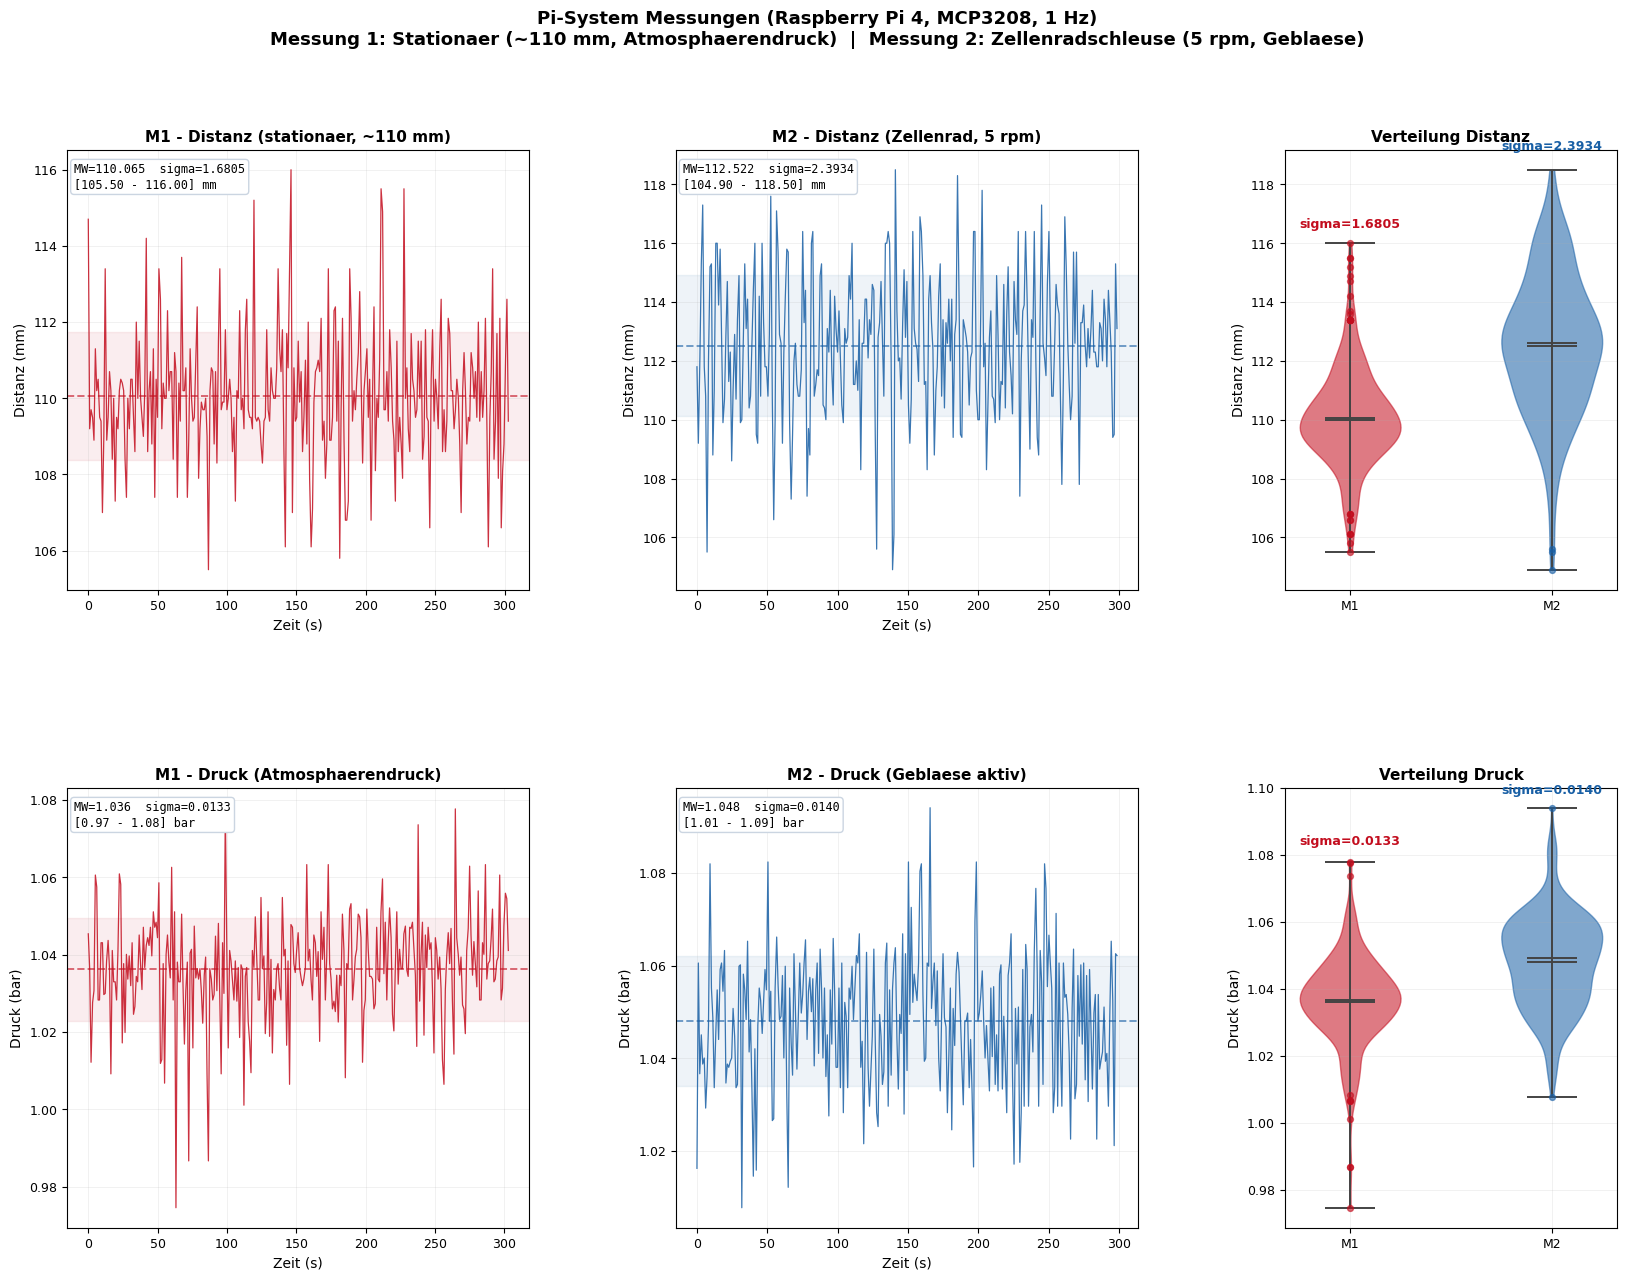

Plot gespeichert: pi_messungen.pdf


In [10]:
# ── Pi-System Visualisierung ──────────────────────────────────────────────────
# Layout: 2 Zeilen x 3 Spalten
#   Spalte 1: Zeitverlauf Messung 1 (rot)
#   Spalte 2: Zeitverlauf Messung 2 (blau)
#   Spalte 3: Violin-Plot (Verteilung + Ausreisser beider Messungen)

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35,
                        width_ratios=[2.5, 2.5, 1.8])

fig.suptitle(
    'Pi-System Messungen (Raspberry Pi 4, MCP3208, 1 Hz)\n'
    'Messung 1: Stationaer (~110 mm, Atmosphaerendruck)  |  '
    'Messung 2: Zellenradschleuse (5 rpm, Geblaese)',
    fontsize=13, fontweight='bold'
)

# Datensaetze fuer Distanz (Reihe 0) und Druck (Reihe 1)
datasets_pi = [
    (0,
     t_pi1_d, v_pi1_d, t_pi2_d, v_pi2_d,
     'M1 - Distanz (stationaer, ~110 mm)',
     'M2 - Distanz (Zellenrad, 5 rpm)',
     'Verteilung Distanz', 'Distanz (mm)', 'mm'),
    (1,
     t_pi1_p, v_pi1_p, t_pi2_p, v_pi2_p,
     'M1 - Druck (Atmosphaerendruck)',
     'M2 - Druck (Geblaese aktiv)',
     'Verteilung Druck', 'Druck (bar)', 'bar'),
]

for row, t1, v1, t2, v2, title1, title2, vtitle, ylabel, unit in datasets_pi:
    m1, s1, mn1, mx1 = stats(v1)   # Statistiken Messung 1
    m2, s2, mn2, mx2 = stats(v2)   # Statistiken Messung 2

    # ── Zeitverlauf Messung 1 ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(t1, v1, color=C_RED, lw=0.9, alpha=0.85)

    # Mittelwert (gestrichelt) und 1-sigma-Band
    ax.axhline(m1, color=C_RED, lw=1.4, ls='--', alpha=0.6)
    ax.axhspan(m1 - s1, m1 + s1, color=C_RED, alpha=0.07)

    ax.set_title(title1, fontsize=11, fontweight='bold')
    ax.set_xlabel('Zeit (s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)

    # Statistik-Box in der oberen linken Ecke
    ax.text(0.015, 0.97,
            f'MW={m1:.3f}  sigma={s1:.4f}\n[{mn1:.2f} - {mx1:.2f}] {unit}',
            transform=ax.transAxes, fontsize=8.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cbd5e1'))

    # ── Zeitverlauf Messung 2 ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[row, 1])
    ax.plot(t2, v2, color=C_BLUE, lw=0.9, alpha=0.85)
    ax.axhline(m2, color=C_BLUE, lw=1.4, ls='--', alpha=0.6)
    ax.axhspan(m2 - s2, m2 + s2, color=C_BLUE, alpha=0.07)
    ax.set_title(title2, fontsize=11, fontweight='bold')
    ax.set_xlabel('Zeit (s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.text(0.015, 0.97,
            f'MW={m2:.3f}  sigma={s2:.4f}\n[{mn2:.2f} - {mx2:.2f}] {unit}',
            transform=ax.transAxes, fontsize=8.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cbd5e1'))

    # ── Violin-Plot: Verteilung M1 und M2 ─────────────────────────────────
    ax = fig.add_subplot(gs[row, 2])

    # Violin: zeigt Verteilungsdichte, Median, Mittelwert und Ausreisser
    parts = ax.violinplot([v1, v2], positions=[1, 2],
                          showmeans=True, showmedians=True, showextrema=True)

    # Farben fuer die Violin-Koerper setzen
    for pc, color in zip(parts['bodies'], [C_RED, C_BLUE]):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
        pc.set_edgecolor(color)

    # Linienelemente (Mittelwert, Median, Whiskers) einheitlich grau
    for part in ['cmeans', 'cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts[part].set_color(C_GRAY)
        parts[part].set_linewidth(1.4)

    # Ausreisser als einzelne Punkte anzeigen (jenseits 1.5 * IQR)
    for i, (v, color) in enumerate([(v1, C_RED), (v2, C_BLUE)], 1):
        q1, q3   = np.percentile(v, 25), np.percentile(v, 75)
        iqr      = q3 - q1
        outliers = v[(v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)]
        if len(outliers):
            ax.scatter([i] * len(outliers), outliers,
                       color=color, s=18, zorder=5, alpha=0.6)

        # Standardabweichung ueber dem Violin anzeigen
        rng = np.max(v) - np.min(v)
        ax.text(i, np.max(v) + rng * 0.05,
                f'sigma={np.std(v):.4f}',
                ha='center', fontsize=9, color=color, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['M1', 'M2'], fontsize=10)
    ax.set_title(vtitle, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)

plt.savefig('pi_messungen.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Plot gespeichert: pi_messungen.pdf")


## 5. Systemvergleich — Pi-System vs. Beckhoff Referenzsystem

**Konvertierung Referenzsystem (Beckhoff EL3174):**
```
Extended Range Scaler: 100% = 30.518 counts (107% = 32.767 = INT16-Maximum)

Distanz: voltage  = raw / 30518 x 10 V
         distance = (voltage / 10) x 485 + 15   [mm]

Druck:   current  = 4 + (raw / 30518) x 16      [mA]
         pressure = (current - 4) / 16 x 1.0    [bar]
```

**Sensoranordnung:**
- Messung 1: *Derselbe* Sensor (UB200 / PP20H) abwechselnd an Pi und Beckhoff angeschlossen
- Messung 2: Distanz = kapazitiver Sensor (Pi) vs. UB200 (Beckhoff); Druck = zweiter PP20H fest in Anlage


In [11]:
# ── Statistische Auswertung Systemvergleich ──────────────────────────────────
print("=" * 70)
print("SYSTEMVERGLEICH - Pi-System vs. Beckhoff EL3174")
print("=" * 70)

# Alle vier Sensorkombinationen vergleichen
comparisons = [
    ("Distanzsensor M1 (stationaer)", v_pi1_d, ref1_d_ds, "mm"),
    ("Distanzsensor M2 (Zellenrad)",  v_pi2_d, ref2_d_ds, "mm"),
    ("Drucksensor M1 (Atmosphaere)",  v_pi1_p, ref1_p_ds, "bar"),
    ("Drucksensor M2 (Geblaese)",     v_pi2_p, ref2_p_ds, "bar"),
]

for name, v_pi, v_ref, unit in comparisons:
    m_pi, s_pi, mn_pi, mx_pi     = stats(v_pi)
    m_ref, s_ref, mn_ref, mx_ref = stats(v_ref)

    print(f"\n{name}:")
    print(f"  {'':20} {'Pi-System':>14} {'Referenz':>14}")
    print(f"  {'':-<48}")
    print(f"  {'Mittelwert':<20} {m_pi:>13.4f} {m_ref:>13.4f}  {unit}")
    print(f"  {'Standardabw.':<20} {s_pi:>13.4f} {s_ref:>13.4f}  {unit}")
    print(f"  {'Min':<20} {mn_pi:>13.4f} {mn_ref:>13.4f}  {unit}")
    print(f"  {'Max':<20} {mx_pi:>13.4f} {mx_ref:>13.4f}  {unit}")
    print(f"  {'Delta MW':<20} {abs(m_pi-m_ref):>13.4f}  {unit}")
    print(f"  {'sigma-Faktor':<20} {s_pi/s_ref:>13.1f}x  (Pi ist {s_pi/s_ref:.1f}x rauschiger)")


SYSTEMVERGLEICH - Pi-System vs. Beckhoff EL3174

Distanzsensor M1 (stationaer):
                            Pi-System       Referenz
  ------------------------------------------------
  Mittelwert                110.0652      111.9543  mm
  Standardabw.                1.6805        0.1137  mm
  Min                       105.5000      111.6726  mm
  Max                       116.0000      112.1335  mm
  Delta MW                    1.8891  mm
  sigma-Faktor                  14.8x  (Pi ist 14.8x rauschiger)

Distanzsensor M2 (Zellenrad):
                            Pi-System       Referenz
  ------------------------------------------------
  Mittelwert                112.5220      113.9644  mm
  Standardabw.                2.3934        1.6278  mm
  Min                       104.9000      110.4012  mm
  Max                       118.5000      117.4415  mm
  Delta MW                    1.4424  mm
  sigma-Faktor                   1.5x  (Pi ist 1.5x rauschiger)

Drucksensor M1 (Atmosphaere):

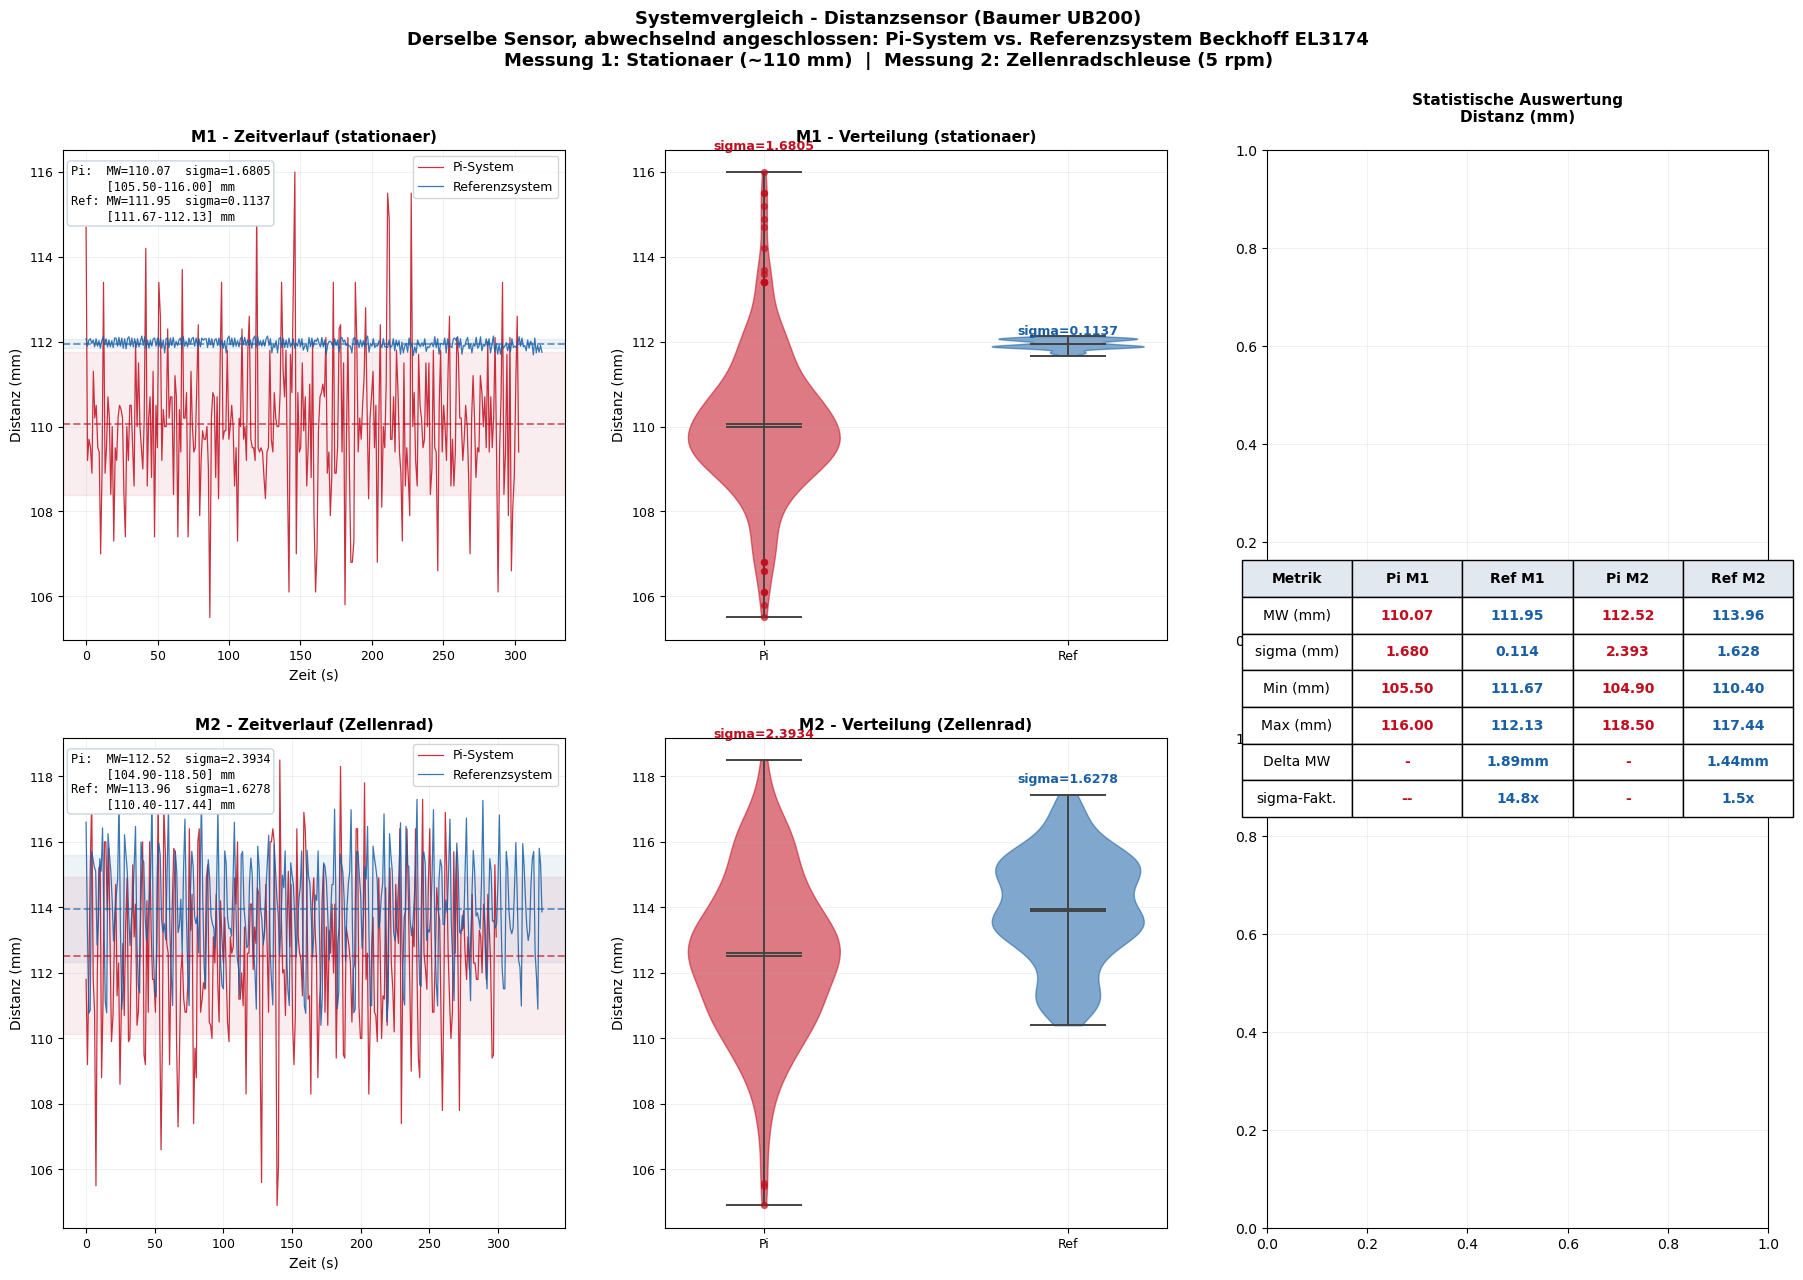

Plot gespeichert: vergleich_distanz.pdf


In [12]:
# ── Distanzsensor Vergleich ───────────────────────────────────────────────────
# Layout: 2 Zeilen x 3 Spalten
#   Zeile 0: Messung 1 (stationaer)
#   Zeile 1: Messung 2 (Zellenrad)
#   Spalte 0: Zeitverlauf Pi vs. Referenz
#   Spalte 1: Violin-Plot
#   Spalte 2: Statistik-Tabelle (beide Reihen gemeinsam)

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle(
    'Systemvergleich - Distanzsensor (Baumer UB200)\n'
    'Derselbe Sensor, abwechselnd angeschlossen: Pi-System vs. Referenzsystem Beckhoff EL3174\n'
    'Messung 1: Stationaer (~110 mm)  |  Messung 2: Zellenradschleuse (5 rpm)',
    fontsize=13, fontweight='bold'
)

dist_data = [
    (axes[0], t_pi1_d, v_pi1_d, t_ref1_ds, ref1_d_ds,
     'M1 - Zeitverlauf (stationaer)'),
    (axes[1], t_pi2_d, v_pi2_d, t_ref2_ds, ref2_d_ds,
     'M2 - Zeitverlauf (Zellenrad)'),
]

for row_axes, t_pi, v_pi, t_ref, v_ref, title in dist_data:
    ax_line = row_axes[0]   # Zeitverlauf
    ax_vio  = row_axes[1]   # Violin-Plot

    # ── Zeitverlauf ────────────────────────────────────────────────────────
    ax_line.plot(t_pi,  v_pi,  color=C_RED,  lw=0.9, alpha=0.85, label='Pi-System')
    ax_line.plot(t_ref, v_ref, color=C_BLUE, lw=0.9, alpha=0.85, label='Referenzsystem')

    # Mittelwertlinien und 1-sigma-Baender fuer beide Systeme
    for v, c in [(v_pi, C_RED), (v_ref, C_BLUE)]:
        m, s = np.mean(v), np.std(v)
        ax_line.axhline(m, color=c, lw=1.4, ls='--', alpha=0.6)
        ax_line.axhspan(m - s, m + s, color=c, alpha=0.07)

    m_pi, s_pi, mn_pi, mx_pi     = stats(v_pi)
    m_ref, s_ref, mn_ref, mx_ref = stats(v_ref)

    # Statistik-Box mit Kennwerten beider Systeme
    ax_line.text(0.015, 0.97,
                 f'Pi:  MW={m_pi:.2f}  sigma={s_pi:.4f}\n'
                 f'     [{mn_pi:.2f}-{mx_pi:.2f}] mm\n'
                 f'Ref: MW={m_ref:.2f}  sigma={s_ref:.4f}\n'
                 f'     [{mn_ref:.2f}-{mx_ref:.2f}] mm',
                 transform=ax_line.transAxes, fontsize=8.5, va='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#cbd5e1'))

    ax_line.set_title(title, fontsize=11, fontweight='bold')
    ax_line.set_xlabel('Zeit (s)', fontsize=10)
    ax_line.set_ylabel('Distanz (mm)', fontsize=10)
    ax_line.legend(fontsize=9)
    ax_line.tick_params(labelsize=9)

    # ── Violin-Plot ────────────────────────────────────────────────────────
    parts = ax_vio.violinplot([v_pi, v_ref], positions=[1, 2],
                               showmeans=True, showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], [C_RED, C_BLUE]):
        pc.set_facecolor(color); pc.set_alpha(0.55); pc.set_edgecolor(color)
    for part in ['cmeans', 'cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts[part].set_color(C_GRAY); parts[part].set_linewidth(1.4)

    # Ausreisser einzeichnen und sigma-Wert anzeigen
    for i, (v, color) in enumerate([(v_pi, C_RED), (v_ref, C_BLUE)], 1):
        q1, q3   = np.percentile(v, 25), np.percentile(v, 75)
        outliers = v[(v < q1 - 1.5*(q3-q1)) | (v > q3 + 1.5*(q3-q1))]
        if len(outliers):
            ax_vio.scatter([i]*len(outliers), outliers,
                           color=color, s=18, zorder=5, alpha=0.6)
        rng = np.max(v) - np.min(v)
        ax_vio.text(i, np.max(v) + rng * 0.05,
                    f'sigma={np.std(v):.4f}',
                    ha='center', fontsize=9, color=color, fontweight='bold')

    ax_vio.set_xticks([1, 2])
    ax_vio.set_xticklabels(['Pi', 'Ref'], fontsize=10)
    ax_vio.set_title(title.replace('Zeitverlauf', 'Verteilung'),
                     fontsize=11, fontweight='bold')
    ax_vio.set_ylabel('Distanz (mm)', fontsize=10)
    ax_vio.tick_params(labelsize=9)

# ── Statistik-Tabelle (rechte Spalte, beide Zeilen) ────────────────────────
# Wird als einzelner Axes ueber beide Zeilen gespannt
ax_tbl = fig.add_subplot(1, 3, 3)
ax_tbl.axis('off')

m1p, s1p, mn1p, mx1p = stats(v_pi1_d)
m1r, s1r, mn1r, mx1r = stats(ref1_d_ds)
m2p, s2p, mn2p, mx2p = stats(v_pi2_d)
m2r, s2r, mn2r, mx2r = stats(ref2_d_ds)

table_data = [
    ['Metrik',     'Pi M1',      'Ref M1',     'Pi M2',      'Ref M2'],
    ['MW (mm)',    f'{m1p:.2f}', f'{m1r:.2f}', f'{m2p:.2f}', f'{m2r:.2f}'],
    ['sigma (mm)', f'{s1p:.3f}', f'{s1r:.3f}', f'{s2p:.3f}', f'{s2r:.3f}'],
    ['Min (mm)',   f'{mn1p:.2f}',f'{mn1r:.2f}',f'{mn2p:.2f}',f'{mn2r:.2f}'],
    ['Max (mm)',   f'{mx1p:.2f}',f'{mx1r:.2f}',f'{mx2p:.2f}',f'{mx2r:.2f}'],
    ['Delta MW',   '-',          f'{abs(m1p-m1r):.2f}mm', '-', f'{abs(m2p-m2r):.2f}mm'],
    ['sigma-Fakt.','--',         f'{s1p/s1r:.1f}x',       '-', f'{s2p/s2r:.1f}x'],
]
tbl = ax_tbl.table(cellText=table_data[1:], colLabels=table_data[0],
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 2.2)

# Kopfzeile hervorheben
for j in range(5):
    tbl[0, j].set_facecolor('#e2e8f0')
    tbl[0, j].set_text_props(fontweight='bold')

# Pi-Werte rot, Referenzwerte blau
for i in range(1, 7):
    tbl[i, 1].set_text_props(color=C_RED,  fontweight='bold')
    tbl[i, 2].set_text_props(color=C_BLUE, fontweight='bold')
    tbl[i, 3].set_text_props(color=C_RED,  fontweight='bold')
    tbl[i, 4].set_text_props(color=C_BLUE, fontweight='bold')

ax_tbl.set_title('Statistische Auswertung\nDistanz (mm)',
                 fontsize=11, fontweight='bold', pad=20)

plt.savefig('vergleich_distanz.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Plot gespeichert: vergleich_distanz.pdf")


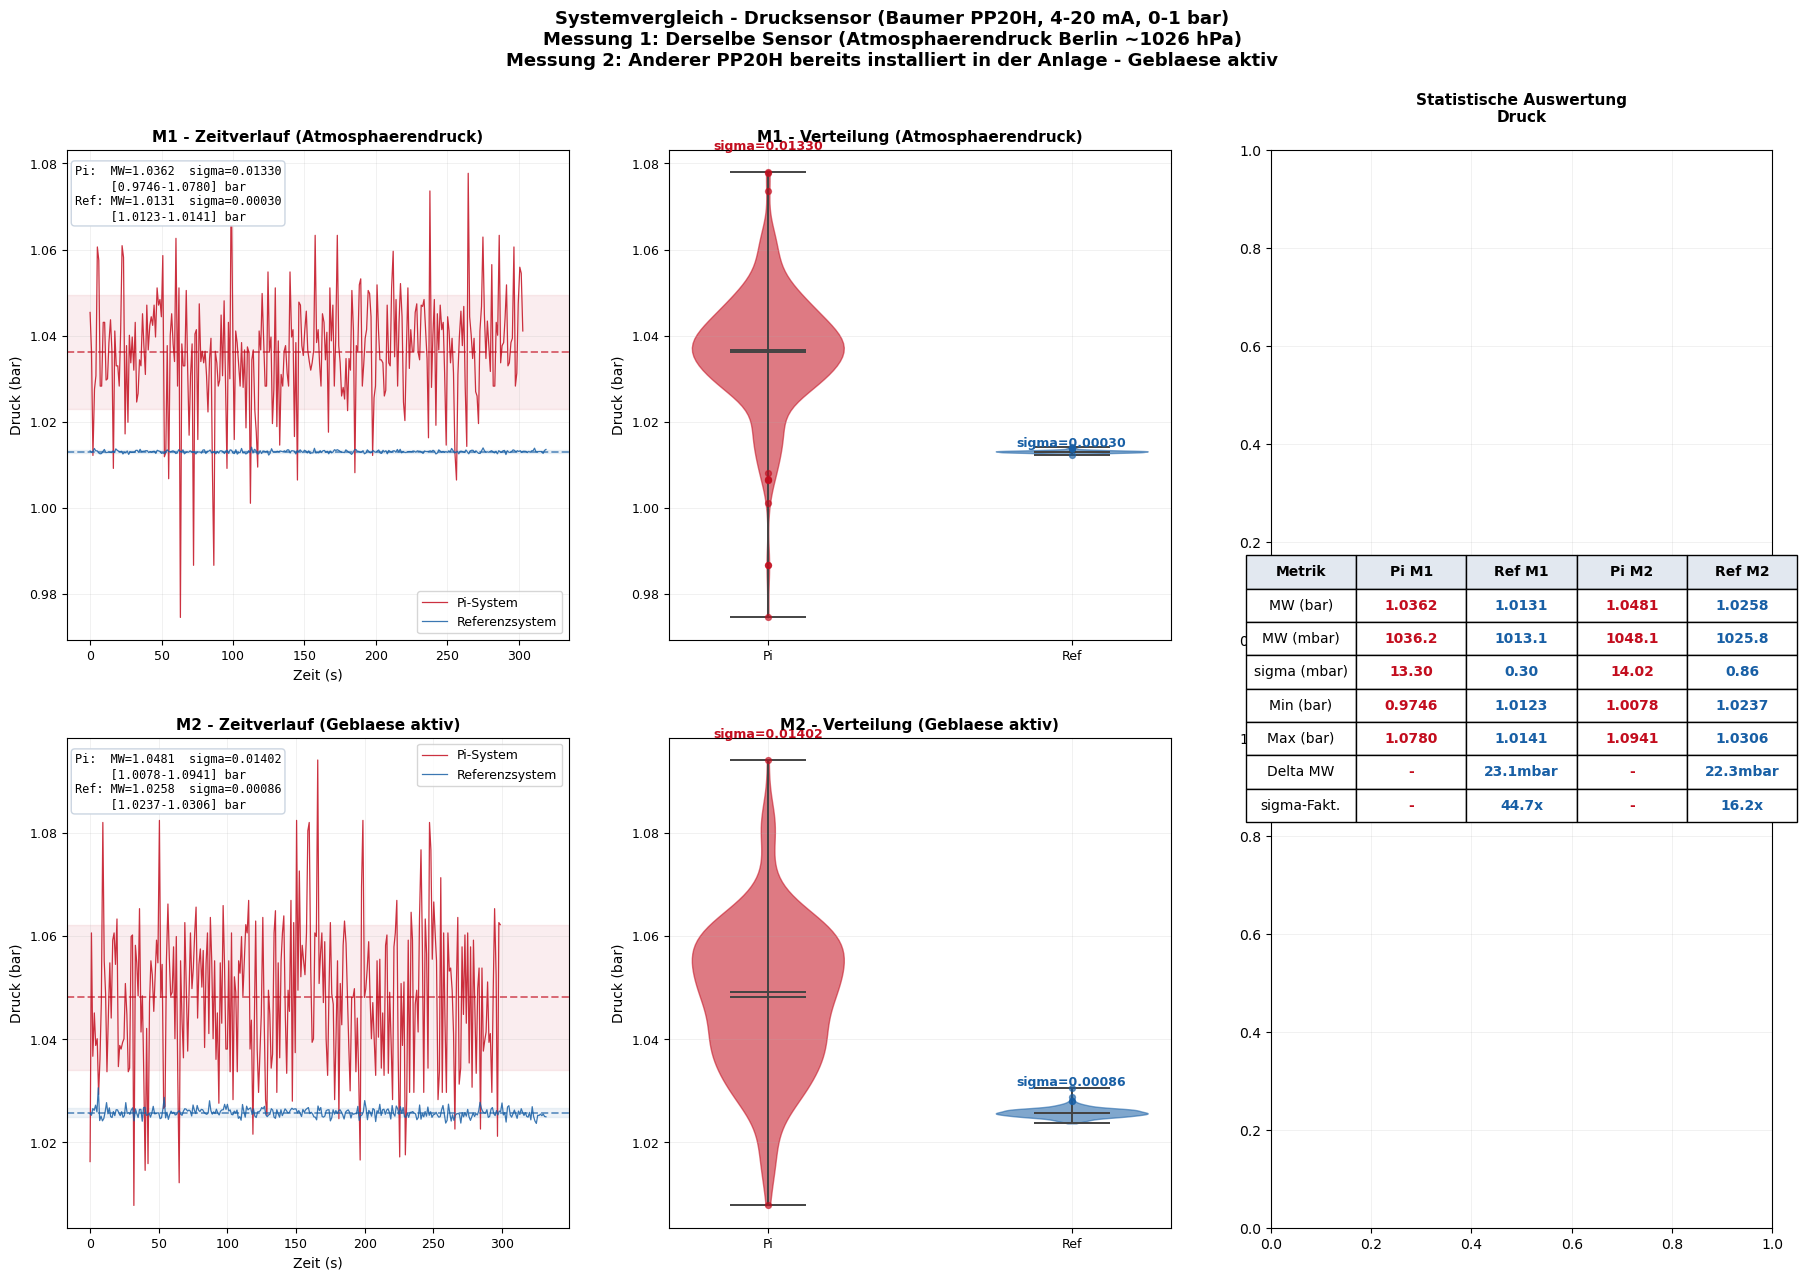

Plot gespeichert: vergleich_druck.pdf


In [13]:
# ── Drucksensor Vergleich ─────────────────────────────────────────────────────
# Gleiche Struktur wie Distanzvergleich

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle(
    'Systemvergleich - Drucksensor (Baumer PP20H, 4-20 mA, 0-1 bar)\n'
    'Messung 1: Derselbe Sensor (Atmosphaerendruck Berlin ~1026 hPa)\n'
    'Messung 2: Anderer PP20H bereits installiert in der Anlage - Geblaese aktiv',
    fontsize=13, fontweight='bold'
)

pres_data = [
    (axes[0], t_pi1_p, v_pi1_p, t_ref1_ds, ref1_p_ds,
     'M1 - Zeitverlauf (Atmosphaerendruck)'),
    (axes[1], t_pi2_p, v_pi2_p, t_ref2_ds, ref2_p_ds,
     'M2 - Zeitverlauf (Geblaese aktiv)'),
]

for row_axes, t_pi, v_pi, t_ref, v_ref, title in pres_data:
    ax_line = row_axes[0]
    ax_vio  = row_axes[1]

    ax_line.plot(t_pi,  v_pi,  color=C_RED,  lw=0.9, alpha=0.85, label='Pi-System')
    ax_line.plot(t_ref, v_ref, color=C_BLUE, lw=0.9, alpha=0.85, label='Referenzsystem')

    for v, c in [(v_pi, C_RED), (v_ref, C_BLUE)]:
        m, s = np.mean(v), np.std(v)
        ax_line.axhline(m, color=c, lw=1.4, ls='--', alpha=0.6)
        ax_line.axhspan(m - s, m + s, color=c, alpha=0.07)

    m_pi, s_pi, mn_pi, mx_pi     = stats(v_pi)
    m_ref, s_ref, mn_ref, mx_ref = stats(v_ref)

    # Statistik-Box (Druckwerte in bar mit 4 Dezimalstellen)
    ax_line.text(0.015, 0.97,
                 f'Pi:  MW={m_pi:.4f}  sigma={s_pi:.5f}\n'
                 f'     [{mn_pi:.4f}-{mx_pi:.4f}] bar\n'
                 f'Ref: MW={m_ref:.4f}  sigma={s_ref:.5f}\n'
                 f'     [{mn_ref:.4f}-{mx_ref:.4f}] bar',
                 transform=ax_line.transAxes, fontsize=8.5, va='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#cbd5e1'))

    ax_line.set_title(title, fontsize=11, fontweight='bold')
    ax_line.set_xlabel('Zeit (s)', fontsize=10)
    ax_line.set_ylabel('Druck (bar)', fontsize=10)
    ax_line.legend(fontsize=9)
    ax_line.tick_params(labelsize=9)

    # Violin-Plot
    parts = ax_vio.violinplot([v_pi, v_ref], positions=[1, 2],
                               showmeans=True, showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], [C_RED, C_BLUE]):
        pc.set_facecolor(color); pc.set_alpha(0.55); pc.set_edgecolor(color)
    for part in ['cmeans', 'cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts[part].set_color(C_GRAY); parts[part].set_linewidth(1.4)
    for i, (v, color) in enumerate([(v_pi, C_RED), (v_ref, C_BLUE)], 1):
        q1, q3   = np.percentile(v, 25), np.percentile(v, 75)
        outliers = v[(v < q1-1.5*(q3-q1)) | (v > q3+1.5*(q3-q1))]
        if len(outliers):
            ax_vio.scatter([i]*len(outliers), outliers,
                           color=color, s=18, zorder=5, alpha=0.6)
        rng = np.max(v) - np.min(v)
        ax_vio.text(i, np.max(v) + rng * 0.05,
                    f'sigma={np.std(v):.5f}',
                    ha='center', fontsize=9, color=color, fontweight='bold')
    ax_vio.set_xticks([1, 2])
    ax_vio.set_xticklabels(['Pi', 'Ref'], fontsize=10)
    ax_vio.set_title(title.replace('Zeitverlauf', 'Verteilung'),
                     fontsize=11, fontweight='bold')
    ax_vio.set_ylabel('Druck (bar)', fontsize=10)
    ax_vio.tick_params(labelsize=9)

# Statistik-Tabelle (Druck, mbar fuer bessere Lesbarkeit)
ax_tbl = fig.add_subplot(1, 3, 3)
ax_tbl.axis('off')

m1p_p, s1p_p, mn1p_p, mx1p_p = stats(v_pi1_p)
m1r_p, s1r_p, mn1r_p, mx1r_p = stats(ref1_p_ds)
m2p_p, s2p_p, mn2p_p, mx2p_p = stats(v_pi2_p)
m2r_p, s2r_p, mn2r_p, mx2r_p = stats(ref2_p_ds)

table_data_p = [
    ['Metrik',      'Pi M1',           'Ref M1',          'Pi M2',           'Ref M2'],
    ['MW (bar)',     f'{m1p_p:.4f}',    f'{m1r_p:.4f}',    f'{m2p_p:.4f}',    f'{m2r_p:.4f}'],
    ['MW (mbar)',    f'{m1p_p*1000:.1f}',f'{m1r_p*1000:.1f}',f'{m2p_p*1000:.1f}',f'{m2r_p*1000:.1f}'],
    ['sigma (mbar)', f'{s1p_p*1000:.2f}',f'{s1r_p*1000:.2f}',f'{s2p_p*1000:.2f}',f'{s2r_p*1000:.2f}'],
    ['Min (bar)',    f'{mn1p_p:.4f}',   f'{mn1r_p:.4f}',   f'{mn2p_p:.4f}',   f'{mn2r_p:.4f}'],
    ['Max (bar)',    f'{mx1p_p:.4f}',   f'{mx1r_p:.4f}',   f'{mx2p_p:.4f}',   f'{mx2r_p:.4f}'],
    ['Delta MW',     '-',               f'{abs(m1p_p-m1r_p)*1000:.1f}mbar', '-', f'{abs(m2p_p-m2r_p)*1000:.1f}mbar'],
    ['sigma-Fakt.',  '-',               f'{s1p_p/s1r_p:.1f}x', '-',          f'{s2p_p/s2r_p:.1f}x'],
]
tbl = ax_tbl.table(cellText=table_data_p[1:], colLabels=table_data_p[0],
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 2.0)
for j in range(5):
    tbl[0, j].set_facecolor('#e2e8f0')
    tbl[0, j].set_text_props(fontweight='bold')
for i in range(1, 8):
    tbl[i, 1].set_text_props(color=C_RED,  fontweight='bold')
    tbl[i, 2].set_text_props(color=C_BLUE, fontweight='bold')
    tbl[i, 3].set_text_props(color=C_RED,  fontweight='bold')
    tbl[i, 4].set_text_props(color=C_BLUE, fontweight='bold')
ax_tbl.set_title('Statistische Auswertung\nDruck',
                 fontsize=11, fontweight='bold', pad=20)

plt.savefig('vergleich_druck.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Plot gespeichert: vergleich_druck.pdf")


## 6. Statistische Zusammenfassung

In [14]:
# ── Gesamtzusammenfassung aller Analysen ─────────────────────────────────────
print("=" * 70)
print("GESAMTZUSAMMENFASSUNG")
print("=" * 70)

# Zenerdiode
print("\nZENERDIODE BENCHMARKING (1N5333B, 3.3V)")
print("-" * 45)
print("Distanzsensor: OHNE sigma=1.137mm  MIT sigma=1.279mm  -> kein Effekt")
print("Drucksensor:   OHNE sigma=0.013bar MIT sigma=0.014bar -> kein Effekt")
print("Fazit: Durchbruchspannung (3.3V) >> ADC-Eingangsspannung (max. 2.41V)")

# Systemvergleich Distanz
s1pd = np.std(v_pi1_d); s1rd = np.std(ref1_d_ds)
s2pd = np.std(v_pi2_d); s2rd = np.std(ref2_d_ds)
m1pd = np.mean(v_pi1_d); m1rd = np.mean(ref1_d_ds)
m2pd = np.mean(v_pi2_d); m2rd = np.mean(ref2_d_ds)

print("\nSYSTEMVERGLEICH - DISTANZ")
print("-" * 45)
print(f"  {'':20} {'Pi-System':>12} {'Referenz':>12} {'Faktor':>8}")
print(f"  {'Distanz M1 (sigma, mm)':<20} {s1pd:>12.3f} {s1rd:>12.3f} {s1pd/s1rd:>7.1f}x")
print(f"  {'Distanz M2 (sigma, mm)':<20} {s2pd:>12.3f} {s2rd:>12.3f} {s2pd/s2rd:>7.1f}x")
print(f"  Delta MW M1: {abs(m1pd-m1rd):.2f} mm  |  Delta MW M2: {abs(m2pd-m2rd):.2f} mm")

# Systemvergleich Druck
s1pp = np.std(v_pi1_p)*1000; s1rp = np.std(ref1_p_ds)*1000
s2pp = np.std(v_pi2_p)*1000; s2rp = np.std(ref2_p_ds)*1000
m1pp = np.mean(v_pi1_p)*1000; m1rp = np.mean(ref1_p_ds)*1000
m2pp = np.mean(v_pi2_p)*1000; m2rp = np.mean(ref2_p_ds)*1000

print("\nSYSTEMVERGLEICH - DRUCK")
print("-" * 45)
print(f"  {'':20} {'Pi-System':>12} {'Referenz':>12} {'Faktor':>8}")
print(f"  {'Druck M1 (sigma, mbar)':<20} {s1pp:>12.2f} {s1rp:>12.2f} {s1pp/s1rp:>7.1f}x")
print(f"  {'Druck M2 (sigma, mbar)':<20} {s2pp:>12.2f} {s2rp:>12.2f} {s2pp/s2rp:>7.1f}x")
print(f"  Delta MW M1: {abs(m1pp-m1rp):.1f} mbar  |  Delta MW M2: {abs(m2pp-m2rp):.1f} mbar")

print("\nINTERPRETATION")
print("-" * 45)
print(f"  Stationaer (M1): Pi ist {s1pd/s1rd:.0f}x rauschiger -> Breadboard-Kontaktrauschen")
print(f"  Dynamisch  (M2): Pi ist {s2pd/s2rd:.1f}x rauschiger -> physik. Bewegung dominiert")
print(f"  Druck-Offset:    ca. {abs(m1pp-m1rp):.0f} mbar -> Kontaktwiderstand im Shunt-Kreis")
print("  Custom PCB wuerde Kontaktwiderstande eliminieren -> deutlich geringeres Rauschen")


GESAMTZUSAMMENFASSUNG

ZENERDIODE BENCHMARKING (1N5333B, 3.3V)
---------------------------------------------
Distanzsensor: OHNE sigma=1.137mm  MIT sigma=1.279mm  -> kein Effekt
Drucksensor:   OHNE sigma=0.013bar MIT sigma=0.014bar -> kein Effekt
Fazit: Durchbruchspannung (3.3V) >> ADC-Eingangsspannung (max. 2.41V)

SYSTEMVERGLEICH - DISTANZ
---------------------------------------------
                          Pi-System     Referenz   Faktor
  Distanz M1 (sigma, mm)        1.680        0.114    14.8x
  Distanz M2 (sigma, mm)        2.393        1.628     1.5x
  Delta MW M1: 1.89 mm  |  Delta MW M2: 1.44 mm

SYSTEMVERGLEICH - DRUCK
---------------------------------------------
                          Pi-System     Referenz   Faktor
  Druck M1 (sigma, mbar)        13.30         0.30    44.7x
  Druck M2 (sigma, mbar)        14.02         0.86    16.2x
  Delta MW M1: 23.1 mbar  |  Delta MW M2: 22.3 mbar

INTERPRETATION
---------------------------------------------
  Stationaer (M1): Pi

## Hinweise zur Reproduzierbarkeit

**Alle CSV-Dateien muessen im selben Ordner wie dieses Notebook liegen.**

| Datei | Inhalt | Zeitraum |
|-------|--------|----------|
| `zener_ohne_distance.csv` | Pi-Distanz OHNE Zener | 17.07.2026, 11:39:41–11:42:15 UTC |
| `zener_ohne_pressure.csv` | Pi-Druck OHNE Zener | 17.07.2026, 11:39:41–11:42:15 UTC |
| `zener_mit_distance.csv` | Pi-Distanz MIT Zener | 17.07.2026, 11:33:04–11:36:32 UTC |
| `zener_mit_pressure.csv` | Pi-Druck MIT Zener | 17.07.2026, 11:33:04–11:36:32 UTC |
| `pi_messung1_distance.csv` | Pi-Distanz M1 | 22.07.2026, 08:42:47–08:47:51 UTC |
| `pi_messung1_pressure.csv` | Pi-Druck M1 | 22.07.2026, 08:42:47–08:47:51 UTC |
| `pi_messung2_distance.csv` | Pi-Distanz M2 | 22.07.2026, 08:57:30–09:02:30 UTC |
| `pi_messung2_pressure.csv` | Pi-Druck M2 | 22.07.2026, 08:57:30–09:02:30 UTC |
| `messung_1-2.csv` | Beckhoff M1 (INT16 Rohdaten) | 22.07.2026 |
| `Messung_2-2.csv` | Beckhoff M2 (INT16 Rohdaten) | 22.07.2026 |

**Ausfuehren:** Alle Zellen nacheinander ausfuehren (`Kernel > Restart & Run All`).  
**Ausgabe:** PDF-Dateien werden automatisch im Notebook-Ordner gespeichert.


---
## 7. Technischer Hintergrund — Signalverarbeitung & Konvertierung

Dieser Abschnitt erläutert die vollständige Signalkette vom physikalischen Messwert 
bis zur angezeigten Größe im Dashboard, sowie die Konvertierungslogik des Beckhoff-Referenzsystems.


### 7.1 Signalkette Pi-System

#### Distanzsensor (Baumer UB200, 0–10 V, Normalmodus)

```
Physikalische Größe     Sensor-Ausgang      Spannungsteiler          ADC              Python
(Abstand in mm)    →   (0–10 V analog)  →  (33 kΩ / 10,5 kΩ)  →  (MCP3208)  →   sensors.py
                                              ↓                       ↓
                                         skaliert auf             12-bit Wert
                                         0–2,41 V max              0–4095
```

**Schritt 1 — Sensor zu Spannungsteiler:**  
Der UB200 gibt eine Spannung zwischen 0 V (Objekt bei 15 mm) und 10 V (kein Objekt, > 500 mm) aus.  
Da der MCP3208 nur 0–3,3 V verarbeiten kann, wird die Spannung durch einen Spannungsteiler reduziert:

$$U_{ADC} = U_{Sensor} \cdot \frac{R_2}{R_1 + R_2} = U_{Sensor} \cdot \frac{10{,}5}{33 + 10{,}5} = U_{Sensor} \cdot 0{,}2414$$

Bei max. 10 V ergibt das: $U_{ADC,max} = 10 \cdot 0{,}2414 = 2{,}41 \text{ V}$ — sicher unter 3,3 V.

**Schritt 2 — ADC-Wandlung (MCP3208, 12-bit):**  
Der MCP3208 wandelt die analoge Spannung in einen digitalen Rohwert um:

$$\text{raw} = \frac{U_{ADC}}{V_{ref}} \cdot 2^{12} = \frac{U_{ADC}}{3{,}3} \cdot 4096$$

Umgekehrt: $U_{ADC} = \text{raw} \cdot \frac{3{,}3}{4096}$

**Schritt 3 — Rohwert zu physikalischer Größe (sensors.py):**  
Zuerst wird die Spannungsteilerwirkung rückgängig gemacht:

$$U_{Sensor} = U_{ADC} \cdot \frac{R_1 + R_2}{R_2} = U_{ADC} \cdot \frac{43{,}5}{10{,}5} = U_{ADC} \cdot 4{,}143$$

Dann die Distanzumrechnung (Normalmodus: 0 V = 15 mm, 10 V = 500 mm, Spanne = 485 mm):

$$d = \frac{U_{Sensor}}{10} \cdot 485 + 15 \quad [\text{mm}]$$

**Beispielrechnung** (raw = 587, typischer Wert bei ~110 mm):
$$U_{ADC} = 587 \cdot \frac{3{,}3}{4096} = 0{,}473 \text{ V}$$
$$U_{Sensor} = 0{,}473 \cdot 4{,}143 = 1{,}960 \text{ V}$$
$$d = \frac{1{,}960}{10} \cdot 485 + 15 = 95{,}1 + 15 = 110{,}1 \text{ mm} \approx 110 \text{ mm} \checkmark$$

---

#### Drucksensor (Baumer PP20H, 4–20 mA, 0–1 bar)

```
Physikalische Größe     Sensor-Ausgang      Shunt-Widerstand         ADC              Python
(Druck in bar)     →   (4–20 mA analog)  →    (150 Ω)          →  (MCP3208)  →   sensors.py
                                              ↓                       ↓
                                         U = I · R               12-bit Wert
                                         0,6–3,0 V                 0–4095
```

**Schritt 1 — Strom zu Spannung (Shunt):**  
Der Strom des 4–20-mA-Signals erzeugt am 150-Ω-Widerstand eine Spannung (Ohmsches Gesetz):

$$U_{Shunt} = I \cdot R = I \cdot 150 \quad [\text{V}]$$

Bei 4 mA: $U = 0{,}004 \cdot 150 = 0{,}60 \text{ V}$ (Nullpunkt)  
Bei 20 mA: $U = 0{,}020 \cdot 150 = 3{,}00 \text{ V}$ (Vollausschlag, unter 3,3 V ✓)

**Schritt 2 — ADC-Wandlung** (identisch zum Distanzsensor)

**Schritt 3 — Rohwert zu physikalischer Größe:**

$$I = \frac{U_{ADC}}{150} \cdot 1000 \quad [\text{mA}]$$

$$p = \frac{I - 4}{16} \cdot 1{,}0 \quad [\text{bar}]$$

(4 mA = Nullpunkt, 20 mA = 1 bar, Spanne = 16 mA)


### 7.2 Konvertierung Beckhoff EL3174 — INT16 zu physikalischer Größe

#### Was ist INT16?

Der Beckhoff-Eingangsklemme EL3174 digitalisiert das analoge Signal und gibt einen 
**vorzeichenlosen 16-Bit-Integer** aus. Ein 16-Bit-Wert kann Zahlen von 0 bis 65.535 darstellen 
(vorzeichenlos) oder –32.768 bis +32.767 (vorzeichenbehaftet). Die EL3174 verwendet den 
vorzeichenlosen Bereich 0–32.767.

#### Warum 30.518 und nicht 32.767?

Die EL3174 unterstützt standardmäßig den sogenannten **Extended Range** (erweiterter Messbereich):

> *„The technical measuring range is ±107 % of the nominal range."*  
> — Beckhoff EL3174 Dokumentation

Das bedeutet: Der Nennbereich (z. B. 0–10 V) entspricht **nicht** dem vollen INT16-Bereich.  
Stattdessen gilt:

| Spannung | INT16-Wert |
|----------|-----------|
| 0 V (0 %) | 0 |
| 10 V (100 %) | **30.518** |
| 10,7 V (107 %) | 32.767 (INT16-Maximum) |

Der Faktor ergibt sich aus: $\frac{32767}{1{,}07} \approx 30.437$ — in der Praxis verwendet Beckhoff 
gerundete 30.518 als festen Skalierungsfaktor.

**Begründung für den Extended Range:**  
In realen Industriesystemen können Sensorsignale kurzzeitig leicht außerhalb des Nennbereichs liegen 
(z. B. durch Druckspitzen, Temperatureffekte, Kalibrierungenauigkeiten). Der Extended Range verhindert 
das digitale Clipping dieser Werte, ohne die Auflösung im Nennbereich zu beeinträchtigen.

#### Umrechnungsformeln

**Distanzsensor (0–10 V Eingang):**

$$U_{Sensor} = \frac{\text{raw}}{30518} \cdot 10 \quad [\text{V}]$$

$$d = \frac{U_{Sensor}}{10} \cdot 485 + 15 \quad [\text{mm}]$$

**Drucksensor (4–20 mA Eingang):**

$$I = 4 + \frac{\text{raw}}{30518} \cdot 16 \quad [\text{mA}]$$

$$p = \frac{I - 4}{16} \cdot 1{,}0 \quad [\text{bar}]$$

**Verifikation** (Messung 1, raw ≈ 6101):
$$U = \frac{6101}{30518} \cdot 10 = 1{,}999 \text{ V} \rightarrow d = \frac{1{,}999}{10} \cdot 485 + 15 = 112{,}0 \text{ mm}$$

Das Referenzsystem liest 112,0 mm, das Pi-System 110,1 mm — beide nahe am eingestellten Sollwert von ~110 mm. 
Die Abweichung von 1,9 mm zwischen den Systemen ist auf unterschiedliche Messpunkte der Sensorgehäuse zurückzuführen. ✓


### 7.3 Zenerdiode 1N5333B (3,3 V) — Wirkungsprinzip und Versuchsergebnis

#### Funktionsprinzip

Eine Zener-Diode leitet in Sperrrichtung, sobald die anliegende Spannung ihre **Durchbruchspannung** 
(auch Zenerspannung $U_Z$) überschreitet. Unterhalb dieser Spannung verhält sie sich wie eine 
normale Diode in Sperrrichtung — kein Strom fließt.

Parallel zum ADC-Eingang geschaltet wirkt sie als **Spannungsklammer**:

```
Signal-Leitung
      │
      ├──── MCP3208 CH-Pin
      │
   [1N5333B]   ← Kathode (+) zur Signalleitung, Anode (–) zu GND
      │
     GND
```

- Signal < $U_Z$: Diode sperrt, kein Einfluss auf das Signal
- Signal > $U_Z$: Diode leitet, Spannung wird auf $U_Z$ begrenzt

Zusätzlich besitzt jede Zener-Diode eine kleine **Sperrschichtkapazität** ($C_J$, typisch 10–200 pF).  
Diese wirkt gemeinsam mit dem Quellwiderstand als passiver **RC-Tiefpassfilter**, der 
hochfrequente Störsignale dämpft — auch wenn die Durchbruchspannung nie erreicht wird.

#### Warum kein messbarer Effekt?

Die maximale Signalspannung am ADC-Eingang beträgt:

$$U_{ADC,max} = 10 \text{ V} \cdot \frac{10{,}5 \text{ k}\Omega}{43{,}5 \text{ k}\Omega} = 2{,}41 \text{ V}$$

Die 1N5333B hat eine Zenerspannung von $U_Z = 3{,}3 \text{ V}$.  
Da $2{,}41 \text{ V} < 3{,}3 \text{ V}$, erreicht das Signal **nie** die Durchbruchspannung.

Der Kapazitätseffekt ist mit $C_J \approx 50 \text{ pF}$ und dem Quellwiderstand  
$R_Q \approx R_1 \| R_2 = \frac{33 \cdot 10{,}5}{43{,}5} \approx 7{,}97 \text{ k}\Omega$  
die Grenzfrequenz des RC-Filters:

$$f_c = \frac{1}{2\pi \cdot R_Q \cdot C_J} = \frac{1}{2\pi \cdot 7970 \cdot 50 \cdot 10^{-12}} \approx 400 \text{ kHz}$$

Da das System nur mit 1 Hz abtastet, sind Störungen bei 400 kHz vollkommen irrelevant.  
**Der Kapazitätseffekt der Diode ist für unser System praktisch wirkungslos.**

#### Messergebnisse

| Sensor | OHNE Zener (σ) | MIT Zener (σ) | Änderung |
|--------|---------------|--------------|---------|
| Distanz | 1,137 mm | 1,279 mm | +12,5 % (kein Effekt) |
| Druck | 0,013 bar | 0,014 bar | +7,7 % (kein Effekt) |

**Empfehlung:** Für wirksame Rauschunterdrückung wäre eine Zener-Diode mit $U_Z \approx 2{,}5$ V  
oder ein RC-Tiefpassfilter mit niedrigerer Grenzfrequenz erforderlich.


---
## 8. Zusammenfassung der Ergebnisse

### 8.1 Zenerdiode Benchmarking

Die Messung der Signalstabilität mit und ohne Zener-Diode (1N5333B, $U_Z = 3{,}3$ V) ergab 
**keinen messbaren positiven Einfluss** auf die Systemgenauigkeit. Die Standardabweichung des 
Distanzsensors erhöhte sich geringfügig von 1,137 mm auf 1,279 mm (+12,5 %), beim Drucksensor 
von 0,013 bar auf 0,014 bar (+7,7 %). Diese Unterschiede liegen innerhalb der normalen 
Messstreuung und sind nicht als systematischer Zener-Effekt zu werten.

Die physikalische Begründung: Die maximale Signalspannung am ADC-Eingang beträgt 2,41 V 
(nach dem 33-kΩ/10,5-kΩ-Spannungsteiler), die Zenerspannung der 1N5333B liegt bei 3,3 V. 
Da der Betriebsbereich die Durchbruchspannung nie erreicht, findet weder eine aktive 
Spannungsbegrenzung noch eine nennenswerte Filterung durch die Sperrschichtkapazität statt.

---

### 8.2 Pi-System Messungen

Das entwickelte Pi-System (Raspberry Pi 4, MCP3208 ADC, Python-Firmware) wurde unter zwei 
Betriebsbedingungen charakterisiert:

**Messung 1 — Stationärer Betrieb:**  
Bei einem festen Objekt im Abstand von ~110 mm und konstantem Atmosphärendruck zeigte das System 
eine Standardabweichung von σ = 1,68 mm (Distanz) bzw. σ = 13,3 mbar (Druck). 
Der Mittelwert von 110,07 mm stimmt gut mit der physischen Distanz überein.  
Der Atmosphärendruck von 1036 mbar liegt nahe am gemessenen Berliner Luftdruck (1026 hPa).

**Messung 2 — Dynamischer Betrieb (Zellenradschleuse):**  
Im Betrieb an der Zellenradschleuse (5 rpm, Gebläse aktiv) erhöhte sich die Standardabweichung 
der Distanzmessung auf σ = 2,39 mm. Diese Zunahme ist auf die reale physikalische Bewegung des 
rotierenden Zellenrads zurückzuführen — kein Systemrauschen, sondern ein echtes Signal.  
Der Drucksensor registrierte einen Überdruckanstieg von ca. 12 mbar durch das Gebläse.

---

### 8.3 Systemvergleich — Pi vs. Beckhoff EL3174

Der direkte Vergleich mit dem professionellen Referenzsystem (Beckhoff TwinCAT, EL3174-Klemme, 
1 kHz Abtastrate) offenbart den erwarteten Unterschied zwischen einem Breadboard-Prototypen 
und einem industriellen Messsystem:

| Sensor | Bedingung | Pi σ | Ref σ | Faktor |
|--------|-----------|------|-------|--------|
| Distanz | Stationär | 1,68 mm | 0,11 mm | **14,8×** |
| Distanz | Zellenrad | 2,39 mm | 1,63 mm | **1,5×** |
| Druck | Stationär | 13,3 mbar | 0,30 mbar | **44,7×** |
| Druck | Zellenrad | 14,0 mbar | 0,86 mbar | **16,2×** |

**Stationärer Betrieb:** Das Pi-System ist 15–45× rauschiger als das Referenzsystem. 
Die Hauptursachen sind Kontaktwiderstände und elektromagnetische Einstreuungen durch die 
Breadboard-Verbindungen und Jumper-Kabel. Diese erhöhen den effektiven Shunt-Widerstand 
(nominell 150 Ω) und verfälschen damit die Strommessung des Drucksensors.

**Dynamischer Betrieb:** Der Rauschunterschied bei der Distanzmessung reduziert sich auf den 
Faktor 1,5× — weil die reale physikalische Bewegung des Zellenrads das Rauschen beider Systeme 
in ähnlicher Größenordnung anhebt. Dies bestätigt, dass das Pi-System das physikalische Signal 
grundsätzlich korrekt erfasst.

**Mittelwertgenauigkeit:** Trotz höherem Rauschen stimmen die Mittelwerte beider Systeme gut überein:
- Distanz: Δ = 1,89 mm (Pi: 110,07 mm, Referenz: 111,95 mm) — systematischer Versatz durch 
  unterschiedliche Messpunkte der Sensorgehäuse
- Druck: Δ = 23 mbar — konsistenter Offset durch den erhöhten Kontaktwiderstand im Pi-Aufbau

---

### 8.4 Schlussfolgerung und Ausblick

Das entwickelte Pi-System ist als **funktionierender Prototyp** zu bewerten, der die grundlegenden 
Anforderungen an ein industrielles Sensor-Dashboard erfüllt: korrekte Sensoranbindung, 
physikalisch plausible Messwerte, Echtzeit-Visualisierung und Datenspeicherung.

Das erhöhte Rauschen gegenüber dem Referenzsystem ist auf den Breadboard-Aufbau zurückzuführen 
und kein fundamentales Problem des gewählten Systemkonzepts. Eine **Custom-PCB mit gelöteten 
Verbindungen** würde die Kontaktwiderstände eliminieren und die Messgenauigkeit erheblich verbessern.

**Weiterführende Maßnahmen:**
1. Custom PCB mit gelöteten SMD-Komponenten (eliminiert Kontaktwiderstände)
2. Differenzieller ADC-Betrieb oder Instrumentenverstärker vor dem ADC (reduziert Gleichtaktstörungen)
3. Korrekte Zener-Diode ($U_Z \approx 2{,}5$ V) oder RC-Tiefpassfilter zur Rauschfilterung
4. Abschirmung der Signalleitungen (reduziert elektromagnetische Einstreuungen)
